### Agentic RAG

In [13]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [14]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [15]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

docs = [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendO

In [ ]:
from langchain_ollama import OllamaEmbeddings

doc_list = [item for sublist in docs for item in sublist ]
#print(doc_list)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_split = text_splitter.split_documents(doc_list)

## Add all the text to vectorDB

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

vectorstore = FAISS.from_documents(
    documents=doc_split,
    embedding=embeddings
)

retriever = vectorstore.as_retriever()

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOv

In [18]:
retriever.invoke("What is LangGraph")

[Document(id='8c31c2ec-2ea9-418a-84b0-e21363567620', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'),
 Document(id='ee67a814-346b-4e38-a559-60545687edc4', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:'),
 Document(id='694a8e3f-d0d8-4af0-8603-8d65fb68dd26', metadata={'source': 'https://d

In [21]:
## retriever to retriever tool
from langchain_core.tools import create_retriever_tool 
retriever_tool = create_retriever_tool(
    retriever,
    "retriever_blog_db_blog",
    "Search and run information about Langgraph"
)

In [22]:
retriever_tool

StructuredTool(name='retriever_blog_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001F269FF21F0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001F269B916F0>)

### Langchain Blogs - Seperate Vector Store


In [25]:
langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/agents",
    "https://docs.langchain.com/oss/python/langchain/short-term-memory"
]

docs = [WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsA

In [26]:
doc_list = [item for sublist in docs for item in sublist]
#print(doc_list)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_split = text_splitter.split_documents(doc_list)

## Add all the text to vectorDB

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

vectorstorelangchain = FAISS.from_documents(
    documents=doc_split,
    embedding=embeddings
)

retrieverlangchain = vectorstorelangchain.as_retriever()

In [27]:
from langchain_core.tools import create_retriever_tool 
retriever_tool_langchain = create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [28]:
tools = [retriever_tool,retriever_tool_langchain]

### Langgraph Workflow

In [29]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [30]:
from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

# llm = ChatOpenAI(model="gpt-4o")

result = llm.invoke("Hello")

In [31]:
result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.02976677, 'completion_tokens_details': None, 'prompt_time': 0.001747931, 'prompt_tokens_details': None, 'queue_time': 0.160869366, 'total_time': 0.031514701}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea6c5-b778-77a3-b1a8-3d4c28754347-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [32]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state.
    Given the question, it will decide to retrieve using the retriever tool,
    or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """

    print("---CALL AGENT---")

    messages = state["messages"]

    model = ChatGroq(model="llama-3.3-70b-versatile")
    model = model.bind_tools(tools)

    response = model.invoke(messages)

    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [35]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

#from langsmith import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

In [36]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")
    
    # LLM
    model = ChatGroq(model="llama-3.3-70b-versatile")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question.
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.\n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question,"context": docs,})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [38]:
from langchain_core.prompts import ChatPromptTemplate
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
        dict: The updated message
    """

    print("---GENERATE---")

    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt

    prompt = ChatPromptTemplate.from_template("""
    Use the following context to answer the question.

    Context:
    {context}

    Question:
    {question}

    Answer:
    """)
    # LLM
    llm = ChatGroq(model="llama-3.3-70b-versatile")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke(
        {
            "context": docs,
            "question": question,
        }
    )

    return {"messages": [response]}

In [39]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")

    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f"""
    Look at the input and try to reason about the underlying semantic intent / meaning. \n
    Here is the initial question:
    \n ------ \n
    {question}
    \n ------- \n

    Formulate an improved question:
    """
            )
        ]
    # Grader
    model = ChatGroq(model="llama-3.3-70b-versatile")

    response = model.invoke(msg)

    return {"messages": [response]}

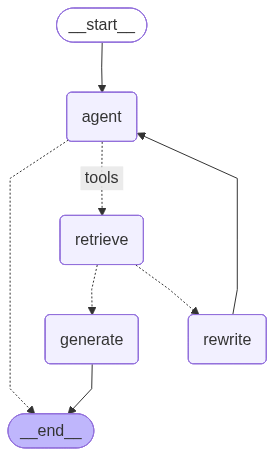

In [42]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent

retrieve = ToolNode([retriever_tool, retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval

workflow.add_node("rewrite", rewrite)  # Re-writing the question

workflow.add_node(
    "generate",
    generate,
)  # Generating a response after we know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
    # Translate the condition outputs to nodes in our graph
    "tools": "retrieve",
    END: END,
},
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import display,Image 
display(Image(graph.get_graph().draw_mermaid_png()))


In [43]:
graph.invoke({"messages":"What is Langgraph"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph', additional_kwargs={}, response_metadata={}, id='40f6b9f4-3e93-45fb-a96c-9f00e632d747'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'b1sw3x7t7', 'function': {'arguments': '{"query":"What is Langgraph"}', 'name': 'retriever_blog_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 309, 'total_tokens': 330, 'completion_time': 0.038447628, 'completion_tokens_details': None, 'prompt_time': 0.027550153, 'prompt_tokens_details': None, 'queue_time': 0.162640596, 'total_time': 0.065997781}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea6dc-875d-7cf2-800b-cb1a13f08b10-0', tool_calls=[{'name': 'retriever_blog_db_blog', 'args': {'query': 'What is Langgraph'}, 'id': 'b1sw3x7t7', 'type': 'tool_call'}], invalid_to